# Compare the glassy phase of negative chain and positive reciprocal motifs

In [2]:
using CairoMakie, Revise
using LinearAlgebra, StatsBase
using LaTeXStrings, JLD2
includet("Utils.jl")
using .Utils
includet("FigureStyles.jl")
using .FigureStyles

In [3]:
# Helper functions

function eigenspectrum_boundary(g::Real, τ; nθ::Int=240)
    τchn, τrec, τcon, τdiv = τ_parser(τ)
    A = 1.0 - τcon - τdiv
    B = τrec - 2τchn
    θ = range(0, 2π, length=nθ)
    return (
        g * (A + B) / sqrt(A) .* cos.(θ),
        g * (A - B) / sqrt(A) .* sin.(θ),
    )
end

function inside_eigenspectrum_boundary(λ::Complex, g::Real, τ; margin::Real=bulk_boundary_margin)
    τchn, τrec, τcon, τdiv = τ_parser(τ)
    A = 1.0 - τcon - τdiv
    B = τrec - 2τchn
    a = abs(g * (A + B) / sqrt(A))
    b = abs(g * (A - B) / sqrt(A))
    return (real(λ) / a)^2 + (imag(λ) / b)^2 ≤ margin^2
end

function plot_mean_trajectories!(ax, example, traces)
    n_traces = min(size(example.mean_x, 2), length(traces))
    for init_idx in 1:n_traces
        y = example.mean_x[:, traces[init_idx]]
        lines!(ax, example.t[1:2:end], y[1:2:end]; linewidth=1.2, alpha=0.8)
    end
end

function plot_convergence_fraction!(ax, results, color; use_abs=false, label=nothing)
    strength = [result.τ_value for result in results]
    if use_abs
        strength = abs.(strength)
    end
    fraction = [result.fraction_converged_mean for result in results]
    fraction_sem = [result.fraction_converged_sem for result in results]

    fraction_lower = max.(0.0, fraction .- fraction_sem)
    fraction_upper = min.(1.0, fraction .+ fraction_sem)

    band!(ax, strength, fraction_lower, fraction_upper; color=(color, 0.4))
    lines!(ax, strength, fraction; color=color, linewidth=1.5, label=label)
    # scatter!(ax, strength, fraction; color=color, markersize=5)
end

function fraction_stable_search_files(dir="results/FPSearch")
    filenames = filter(filename -> startswith(filename, "FractionStableSearch_") && endswith(filename, ".jld2"), readdir(dir))
    return joinpath.(dir, sort(filenames))
end

function fp_strength_groups(records, strength)
    groups = Dict{Float64, Vector{Any}}()
    for record in records
        push!(get!(groups, strength(record), Any[]), record)
    end
    return sort(collect(groups); by=group -> group[1])
end

function mean_sem(values; dims=nothing, center=mean, spread=:sem)
    if dims === nothing
        values = filter(!isnan, collect(values))
        y_mean = isempty(values) ? NaN : center(values)
        y_sem = if length(values) <= 1
            0.0
        else
            s = std(values)
            spread === :sd ? s : s / sqrt(length(values))
        end
        return y_mean, y_sem
    end

    y_mean = vec(mean(values; dims=dims))
    n = size(values, dims)
    y_sem = if n == 1
        zeros(length(y_mean))
    else
        s = vec(std(values; dims=dims))
        spread === :sd ? s : s ./ sqrt(n)
    end
    return y_mean, y_sem
end

function load_fp_summary(filename; stable_eig_threshold=-1e-6)
    data = load(filename)
    result = data["search_result"]
    τrec = hasproperty(result, :τrec) ? result.τrec : data["τrec"]
    τchn = hasproperty(result, :τchn) ? result.τchn : get(data, "τchn", 0.0)
    n_fp = result.n_fp
    n_stable_fp = count(fp -> fp.max_real_eig < stable_eig_threshold, result.fixed_points)
    fraction_stable = iszero(n_fp) ? NaN : n_stable_fp / n_fp
    return (; filename, τrec, τchn, complexity=log(n_fp) / data["N"], fraction_stable=100fraction_stable)
end

function fixed_point_metric_points(records, motif, metric; xvalue=identity, center=mean, spread=:sem)
    is_iid(record) = iszero(record.τrec) && iszero(record.τchn)
    motif_strength = motif === :chn ? (record -> record.τchn) : (record -> record.τrec)
    is_motif(record) = motif === :chn ? (iszero(record.τrec) && !iszero(record.τchn)) : (!iszero(record.τrec) && iszero(record.τchn))

    x = Float64[0.0]
    y_mean = Float64[]
    y_sem = Float64[]
    iid_mean, iid_sem = mean_sem((metric(record) for record in filter(is_iid, records)); center, spread)
    push!(y_mean, iid_mean)
    push!(y_sem, iid_sem)

    for (τ, group) in fp_strength_groups(filter(is_motif, records), motif_strength)
        group_mean, group_sem = mean_sem((metric(record) for record in group); center, spread)
        push!(x, xvalue(τ))
        push!(y_mean, group_mean)
        push!(y_sem, group_sem)
    end

    order = sortperm(x)
    return (; x=x[order], y_mean=y_mean[order], y_sem=y_sem[order])
end

function plot_metric_by_tau!(ax, points, color)
    lines!(ax, points.x, points.y_mean; color=color, linewidth=1.5, alpha=0.9)
    errorbars!(ax, points.x, points.y_mean, points.y_sem; color=color, whiskerwidth=0, alpha=0.8)
    scatter!(ax, points.x, points.y_mean; color=color, markersize=5)
end

function right_axis!(figpos; color, ylabel)
    ax = Axis(figpos;
        yaxisposition=:right,
        ylabel=ylabel,
        ylabelcolor=color,
        ytickcolor=color,
        yticklabelcolor=color,
        xgridvisible=false,
        ygridvisible=false,
        backgroundcolor=:transparent,
        ylabelsize=11)
    hidexdecorations!(ax; grid=false)
    hidespines!(ax, :l, :t, :b)
    ax.rightspinevisible = true
    ax.rightspinecolor = color
    return ax
end

function load_fp_curve(filename)
    data = load(filename)
    result = data["search_result"]
    N = data["N"]
    τrec = hasproperty(result, :τrec) ? result.τrec : data["τrec"]
    τchn = hasproperty(result, :τchn) ? result.τchn : get(data, "τchn", 0.0)

    return (;
        filename,
        τrec,
        τchn,
        x=getproperty.(result.distinct_fp_by_ic, :n_ic),
        y=log.(getproperty.(result.distinct_fp_by_ic, :n_fp)) ./ N,
    )
end

function plot_mean_sem!(ax, curves, color; label, linestyle=:solid)
    min_len = minimum(length(curve.x) for curve in curves)
    x = curves[1].x[1:min_len]
    y_by_seed = hcat([curve.y[1:min_len] for curve in curves]...)
    y_mean, y_sem = mean_sem(y_by_seed; dims=2)

    band!(ax, x, y_mean .- y_sem, y_mean .+ y_sem; color=(color, 0.25))
    lines!(ax, x, y_mean; color=color, linewidth=2.5, linestyle=linestyle, label=label, alpha=0.9)
end

function motif_colors(n)
    palette = cgrad(:navia, max(n + 2, 3), categorical=true)
    return [palette[i + 1] for i in 1:n]
end

motif_colors (generic function with 1 method)

In [4]:
stable_eig_threshold = -1e-6
fp_search_dir = "results/FPSearch"
fp_search_files = joinpath.(
    fp_search_dir,
    sort(filter(
        filename -> startswith(filename, "FractionStableSearch_") && endswith(filename, ".jld2"),
        readdir(fp_search_dir),
    )),
)

for filename in fp_search_files
    data = load(filename)
    result = data["search_result"]
    seed = data["seed"]
    τrec = hasproperty(result, :τrec) ? result.τrec : data["τrec"]
    τchn = hasproperty(result, :τchn) ? result.τchn : get(data, "τchn", 0.0)
    n_stable_fp = count(fp -> fp.max_real_eig < stable_eig_threshold, result.fixed_points)
    fraction_stable = iszero(result.n_fp) ? NaN : n_stable_fp / result.n_fp

    println(basename(filename))
    println("seed = $seed")
    println("  τrec = $τrec, τchn = $τchn, g = $(result.g)")
    println("  fraction_converged = $(result.convergence_rate)")
    println("  distinct_fixed_points = $(result.n_fp)")
    println("  stable_fixed_points = $n_stable_fp")
    println("  fraction_stable = $fraction_stable")
    println("  residual_mean = $(result.residual_mean)")
    println("  residual_max = $(result.residual_max)")
    println()
end

FractionStableSearch_taurec0p0_tauchn-0p07_seed1.jld2
seed = 1
  τrec = 0.0, τchn = -0.07, g = 2.7820855486487113
  fraction_converged = 2.1564049
  distinct_fixed_points = 573
  stable_fixed_points = 2
  fraction_stable = 0.0034904013961605585
  residual_mean = 5.304741386326968e-12
  residual_max = 4.639132220368824e-11

FractionStableSearch_taurec0p0_tauchn-0p07_seed2.jld2
seed = 2
  τrec = 0.0, τchn = -0.07, g = 2.7820855486487113
  fraction_converged = 2.5184465
  distinct_fixed_points = 2307
  stable_fixed_points = 2
  fraction_stable = 0.0008669267446900737
  residual_mean = 5.009086615322157e-12
  residual_max = 4.331583763427283e-11

FractionStableSearch_taurec0p0_tauchn-0p07_seed3.jld2
seed = 3
  τrec = 0.0, τchn = -0.07, g = 2.7820855486487113
  fraction_converged = 3.2990998
  distinct_fixed_points = 779
  stable_fixed_points = 2
  fraction_stable = 0.0025673940949935813
  residual_mean = 5.1023455986557635e-12
  residual_max = 4.455021876449011e-11

FractionStableSearch_ta

In [5]:
# example eigenspectrum bulk
using Random
Random.seed!(123)
g_eff = 3.0
τchn_vec = [0.0, -0.075, -0.15]
J0 = 0.0
N = 2000
bulk_boundary_margin = 1.05
eigenvals = Vector{Vector{ComplexF64}}()
g_vec = Float64[]
for (i, τchn) in enumerate(τchn_vec)
    τ = (τchn, 0.0)
    g = compute_g(g_eff, τ)
    J = CreateJ(N, J0, g, τ; parallel=false, verbose=false)
    J === nothing && error("CreateJ failed for τ = $τ.")
    e_vals = eigvals(J)
    push!(eigenvals, e_vals)
    push!(g_vec, g)
end


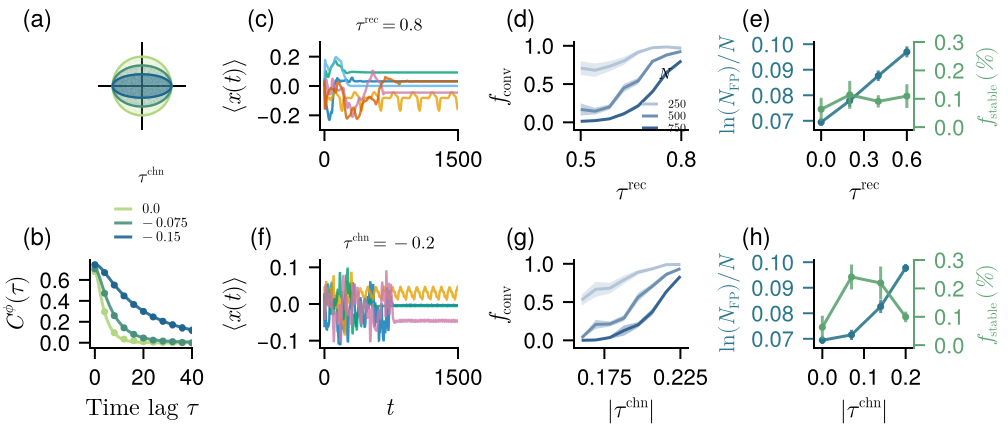

CairoMakie.Screen{PDF}


In [6]:
set_theme!(DoubleColumnTheme)
colors = cgrad(:navia, 12, categorical=true)
colors = reverse(colors[[4,7,10]])

fig = Figure(size=(7*72, 3*72), figure_padding=(2f0,5f0,5f0,2f0))
fig_grid = fig[1,1] = GridLayout()
ax = Axis(fig_grid[1, 1];
    xlabel=L"\mathrm{Re}\,\lambda",
    ylabel=L"\mathrm{Im}\,\lambda",
    aspect=1, limits=(-4.5, 4.5, -4.5, 4.5))

hlines!(ax, 0; color = :black, linewidth = 1.0)
vlines!(ax, 0; color = :black, linewidth = 1.0)

for (i, τchn) in enumerate(τchn_vec)
    color = colors[i]
    τ = (τchn, 0.0)
    λ = filter(λ -> inside_eigenspectrum_boundary(λ, g_vec[i], τ), eigenvals[i])
    scatter!(ax, real.(λ), imag.(λ);
        color=(color, 0.1), markersize=1.5, rasterize=10)

    bx, by = eigenspectrum_boundary(g_vec[i], τ)
    lines!(ax, bx, by; color=color, linewidth=1.2, label=L"%$(τchn)")
end

hidespines!(ax)
hidedecorations!(ax)

# Run DMFTNegChnComparison.jl
data = load("results/DMFTChaosCompNegChn.jld2")
results = data["results"]
τchn_vec = data["τchn_vec"]

ax2 = Axis(fig_grid[2, 1],
    xlabel=L"\text{Time lag } τ",
    ylabel=L"C^{\phi}(τ)",
    xticks=[0.0,20.0,40.0],
    limits=(-2.0, 40.0, -0.05, nothing)
)

for i in 1:3
    num = results[i].NumericalResult
    numerical_idx = 1:8:length(num.times)
    dmft = results[i].DMFTResult

    Cϕ_num = num.Cϕ_mean[numerical_idx]
    lower = num.Cϕ_std[numerical_idx]
    upper = num.Cϕ_std[numerical_idx]

    Cϕ_dmft = dmft.Cϕ
    lines!(ax2, dmft.times, dmft.Cϕ,
        color=colors[i], linewidth=1.5, label=L"%$(τchn_vec[i])", alpha=0.9)
    scatter!(ax2, num.times[numerical_idx], Cϕ_num; markersize=5, color=colors[i])
    errorbars!(ax2, num.times[numerical_idx], Cϕ_num, lower, upper, color=colors[i], alpha=0.8)
end
axislegend(ax2, L"\tau^{\mathrm{chn}}"; titlesize=9, position=(0.0, -2.1), framevisible=false, 
                labelsize=7, patchsize=(9, 5), rowgap=0)

# Run ConvergeFractionSearch.jl
data = load("results/ConvergeFractionSearch.jld2")

convergence_results = data["ConvergenceFractionByN"]
examples = data["MeanTrajectoryExamples"]


ax_rec = Axis(fig_grid[1, 2];
    ylabel=L"\langle x(t)\rangle",
    title=L"\tau^{\mathrm{rec}} = %$(examples.rec.τ_value)",
    titlesize=9,
    limits=(-50.0, 1500.0, -0.3, 0.3), 
    yticks=[-0.2,0.0,0.2],
    xticks=[0.0,1500.0])
ax_chn = Axis(fig_grid[2, 2];
    xlabel=L"t",
    ylabel=L"\langle x(t)\rangle",
    title=L"\tau^{\mathrm{chn}} = %$(examples.chn.τ_value)",
    titlesize=9,
    limits=(-50.0, 1500.0, -0.12, 0.12), 
    yticks=[-0.1,0.0,0.1],
    xticks=[0.0,1500.0])
ax_rec_fraction = Axis(fig_grid[1, 3];
    xlabel=L"\tau^{\mathrm{rec}}",
    ylabel=L"f_{\mathrm{conv}}", 
    xticks=[0.5, 0.8],
    limits=(0.48, 0.82, -0.1, 1.05))
ax_chn_fraction = Axis(fig_grid[2, 3];
    xlabel=L"|\tau^{\mathrm{chn}}|",
    ylabel=L"f_{\mathrm{conv}}", 
    xticks=[0.175, 0.225],
    limits=(0.155, 0.23, -0.1, 1.05))

rec_traces = [5,6,7,10,11,12]
plot_mean_trajectories!(ax_rec, examples.rec, rec_traces)
chn_traces = [3,7,8,11]
plot_mean_trajectories!(ax_chn, examples.chn, chn_traces)

colors = cgrad(:cork, 28, categorical=true)
N_colors = reverse(colors[[6,9,12]])
for (i, result_by_N) in enumerate(convergence_results)
    color = N_colors[i]
    plot_convergence_fraction!(ax_rec_fraction, result_by_N.rec, color; label=L"%$(result_by_N.N)")
    plot_convergence_fraction!(ax_chn_fraction, result_by_N.chn, color; use_abs=true)
end
axislegend(ax_rec_fraction, L"N"; titlesize=8, position=(2.0,1.0), labelsize=6, framevisible=false, patchsize=(8, 4), rowgap=0)

axis_colors = cgrad(:navia, 12, categorical=true)[[5, 8]]
complexity_color, stable_color = axis_colors

ax_rec = Axis(fig_grid[1, 4];
    xlabel=L"\tau^{\mathrm{rec}}",
    ylabel=L"\ln (N_{\mathrm{FP}})/N",
    ylabelcolor=complexity_color,
    ytickcolor=complexity_color,
    yticklabelcolor=complexity_color, 
    xticks=[0.0,0.3,0.6], 
    ylabelsize=11)
ax_chn = Axis(fig_grid[2, 4];
    xlabel=L"|\tau^{\mathrm{chn}}|",
    ylabel=L"\ln (N_{\mathrm{FP}})/N",
    ylabelcolor=complexity_color,
    ytickcolor=complexity_color,
    yticklabelcolor=complexity_color, 
    xticks=[0.0,0.1,0.2],
    ylabelsize=11)

ax_rec_stable = right_axis!(fig_grid[1, 4]; color=stable_color, ylabel=L"f_{\mathrm{stable}}\,(%)")
ax_chn_stable = right_axis!(fig_grid[2, 4]; color=stable_color, ylabel=L"f_{\mathrm{stable}}\,(%)")

stable_eig_threshold = -1e-6
# Run FractionStableSearch.jl
fp_summary = [load_fp_summary(filename; stable_eig_threshold) for filename in fraction_stable_search_files()]
stable_center = mean  # choose `mean` or `median`
stable_spread = :sem  # choose `:sem` or `:sd`
chn_complexity = fixed_point_metric_points(fp_summary, :chn, record -> record.complexity; xvalue=abs, spread=:sem)
rec_complexity = fixed_point_metric_points(fp_summary, :rec, record -> record.complexity; spread=:sem)
chn_stable = fixed_point_metric_points(fp_summary, :chn, record -> record.fraction_stable; xvalue=abs, center=stable_center, spread=stable_spread)
rec_stable = fixed_point_metric_points(fp_summary, :rec, record -> record.fraction_stable; center=stable_center, spread=stable_spread)

plot_metric_by_tau!(ax_chn, chn_complexity, complexity_color)
plot_metric_by_tau!(ax_rec, rec_complexity, complexity_color)
plot_metric_by_tau!(ax_chn_stable, chn_stable, stable_color)
plot_metric_by_tau!(ax_rec_stable, rec_stable, stable_color)

linkxaxes!(ax_chn, ax_chn_stable)
linkxaxes!(ax_rec, ax_rec_stable)
linkyaxes!(ax_chn, ax_rec)
linkyaxes!(ax_chn_stable, ax_rec_stable)
ax_rec_stable.limits = (-0.05,0.65,-0.01,0.3)
ax_chn_stable.limits = (-0.02,0.22,-0.01,0.3)
ax_rec_stable.yticks = 0.0:0.1:0.3
ax_chn_stable.yticks = 0.0:0.1:0.3
colsize!(fig_grid, 2, 0.96*72)
colsize!(fig_grid, 3, 0.8*72)
colsize!(fig_grid, 4, 0.7*72)
colgap!(fig_grid, 15)
rowgap!(fig_grid, 10)


Label(fig_grid[1, 1, TopLeft()], "(a)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[2, 1, TopLeft()], "(b)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[1, 2, TopLeft()], "(c)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[1, 3, TopLeft()], "(d)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[1, 4, TopLeft()], "(e)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[2, 2, TopLeft()], "(f)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[2, 3, TopLeft()], "(g)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
Label(fig_grid[2, 4, TopLeft()], "(h)"; fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))

display(fig)
# save("images/ConvergeFractionSearch.pdf", fig, pt_per_unit=1)

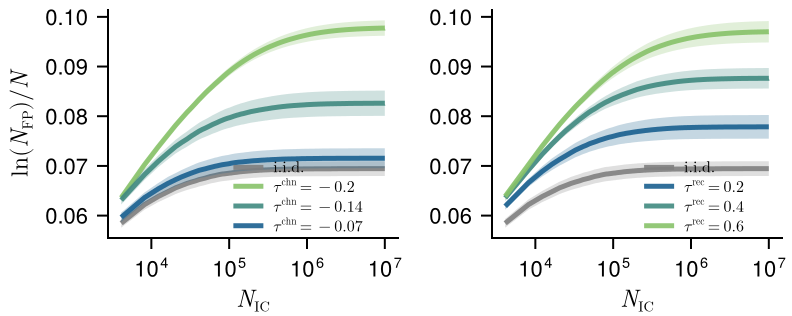

CairoMakie.Screen{PDF}


In [7]:
fp_search_files = fraction_stable_search_files()

fp_curves = load_fp_curve.(fp_search_files)
iid_curves = filter(curve -> iszero(curve.τrec) && iszero(curve.τchn), fp_curves)
chn_groups = fp_strength_groups(
    filter(curve -> iszero(curve.τrec) && !iszero(curve.τchn), fp_curves),
    curve -> curve.τchn,
)
rec_groups = fp_strength_groups(
    filter(curve -> !iszero(curve.τrec) && iszero(curve.τchn), fp_curves),
    curve -> curve.τrec,
)
set_theme!(DoubleColumnTheme)
f = Figure(size=(5.5*72, 2.2*72), figure_padding=(5, 5, 2, 5))
ax_chn = Axis(f[1, 1];
    xlabel=L"N_{\mathrm{IC}}",
    ylabel=L"\ln (N_{\mathrm{FP}})/N",
    xscale=log10)
ax_rec = Axis(f[1, 2];
    xlabel=L"N_{\mathrm{IC}}",
    xscale=log10)

for ax in (ax_chn, ax_rec)
    plot_mean_sem!(ax, iid_curves, :gray; label=L"\mathrm{i.i.d.}", linestyle=:solid)
end

for ((τchn, curves), color) in zip(chn_groups, reverse(motif_colors(length(chn_groups))))
    plot_mean_sem!(ax_chn, curves, color; label=L"\tau^{\mathrm{chn}} = %$(τchn)")
end

for ((τrec, curves), color) in zip(rec_groups, motif_colors(length(rec_groups)))
    plot_mean_sem!(ax_rec, curves, color; label=L"\tau^{\mathrm{rec}} = %$(τrec)")
end

axislegend(ax_chn; position=(0.9, -0.2), labelsize=8, framevisible=false, patchsize=(15, 5), rowgap=1)
axislegend(ax_rec; position=(0.9, -0.2), labelsize=8, framevisible=false, patchsize=(15, 5), rowgap=1)
linkxaxes!(ax_chn, ax_rec)
linkyaxes!(ax_chn, ax_rec)
colgap!(f.layout, 16)

display(f)
# save("images/FractionStableSearchDistinctByIC.pdf", f, pt_per_unit=1)